How do the demographic profiles (sex, age, race, etc.) of the Thyroid Visit cohort compare with patients who received TSH, T3, or T4 testing? Does the data reflect expected real-world clinical trends, such as higher thyroid risk in women in their 40s and 50s?

In [4]:
import pandas as pd

#read the cleaned data
df_diag = pd.read_csv('visits_analysis_ready.csv')
df_test = pd.read_csv('thyroid_testing_cohort.csv')

# check the loaded data
display(df_diag.head())
print(f"diagnosed_visit: {len(df_diag)}row")
print(f"tested_patient: {len(df_test)}row")

,person_id,gender_concept_id,gender,gender_clean,year_of_birth,age_at_visit,age_group,race,race_clean,ethnicity,...,visit_start_date,visit_end_date,visit_duration_days,same_day_visit_flag,long_visit_flag_7d,long_visit_flag_30d,office_related_flag,inpatient_related_flag,emergency_related_flag,telehealth_flag
0,924609883,8532,F,F,1956.0,69.0,65+,White,White,Not Hispanic or Latino,...,2025-11-21,2026-01-18,58.0,0,1,1,1,0,0,0
1,426015508,8532,F,F,1932.0,93.0,65+,White,White,Not Hispanic or Latino,...,2025-08-01,2025-08-03,2.0,0,0,0,1,0,0,0
2,178569665,8532,F,F,1979.0,46.0,35-49,Black or African American,Black or African American,Not Hispanic or Latino,...,2025-05-15,2025-06-08,24.0,0,1,0,0,0,0,1
3,749236674,8507,M,M,1964.0,61.0,50-64,White,White,Not Hispanic or Latino,...,2025-08-19,2025-09-20,32.0,0,1,1,1,0,0,0
4,82232424,8532,F,F,1994.0,31.0,18-34,Other,Other,Not Hispanic or Latino,...,2025-06-10,2025-08-23,74.0,0,1,1,1,0,0,0


diagnosed_visit: 179124row
tested_patient: 42300row


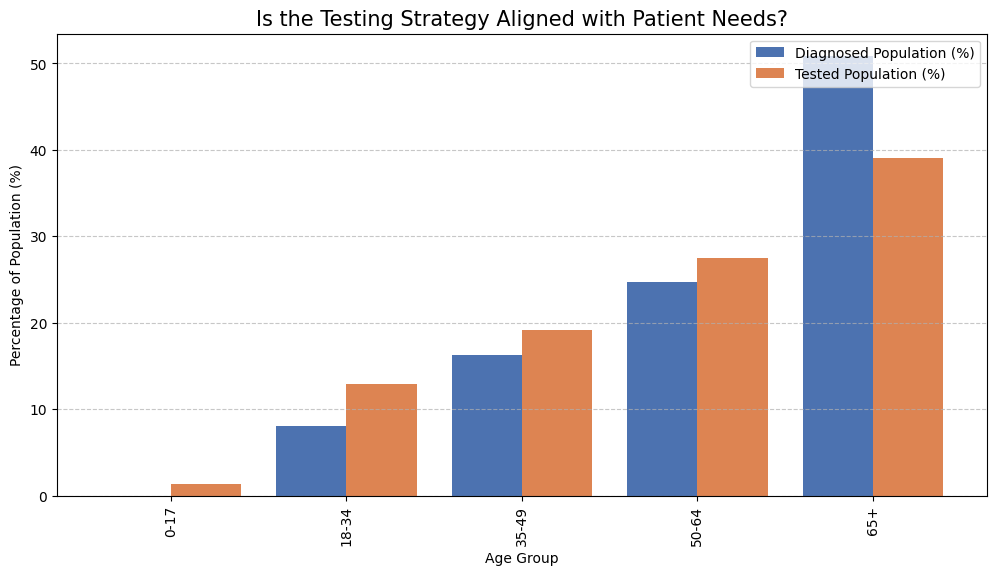

--- Age Group Comparison ---
           Diagnosed Population (%)  Tested Population (%)
age_group                                                 
0-17                           0.00                   1.38
18-34                          8.07                  12.89
35-49                         16.28                  19.20
50-64                         24.75                  27.53
65+                           50.90                  39.00


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Identify unique diagnosed patients
df_diag_unique = df_diag.drop_duplicates(subset='person_id')
df_test_unique = df_test 

# 2. Calculate age group distributions
diag_age_dist = df_diag_unique['age_group'].value_counts(normalize=True).sort_index() * 100
test_age_dist = df_test_unique['age_group'].value_counts(normalize=True).sort_index() * 100

# 3. create a comparison table
comparison_df = pd.DataFrame({
    'Diagnosed Population (%)': diag_age_dist,
    'Tested Population (%)': test_age_dist
}).fillna(0)

# 4. Visualize result using a bar plot
ax = comparison_df.plot(kind='bar', figsize=(12, 6), width=0.8, color=['#4C72B0', '#DD8452'])
plt.title('Is the Testing Strategy Aligned with Patient Needs?', fontsize=15)
plt.ylabel('Percentage of Population (%)')
plt.xlabel('Age Group')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.show()

# display a numeric summary table
print("--- Age Group Comparison ---")
print(comparison_df.round(2))

There is a lack of test in +65 group.

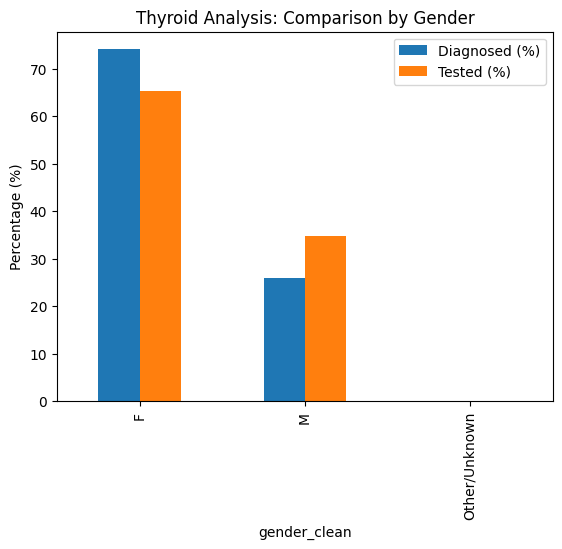

Gender Comparison Table:
               Diagnosed (%)  Tested (%)
gender_clean                            
F                      74.07       65.24
M                      25.90       34.76
Other/Unknown           0.03        0.00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
# Calculate percentages for gender distribution
diag_gender = df_diag_unique['gender_clean'].value_counts(normalize=True) * 100
test_gender = df_test['gender_clean'].value_counts(normalize=True) * 100

# Create comparison table and plot
df_gender_comp = pd.DataFrame({'Diagnosed (%)': diag_gender, 'Tested (%)': test_gender}).fillna(0)
df_gender_comp.plot(kind='bar', title='Thyroid Analysis: Comparison by Gender')
plt.ylabel('Percentage (%)')
plt.show()

# Display numeric results
print("Gender Comparison Table:")
print(df_gender_comp.round(2))

males are being over-tested relative to their diagnostic risk, while high-risk females are under-tested.


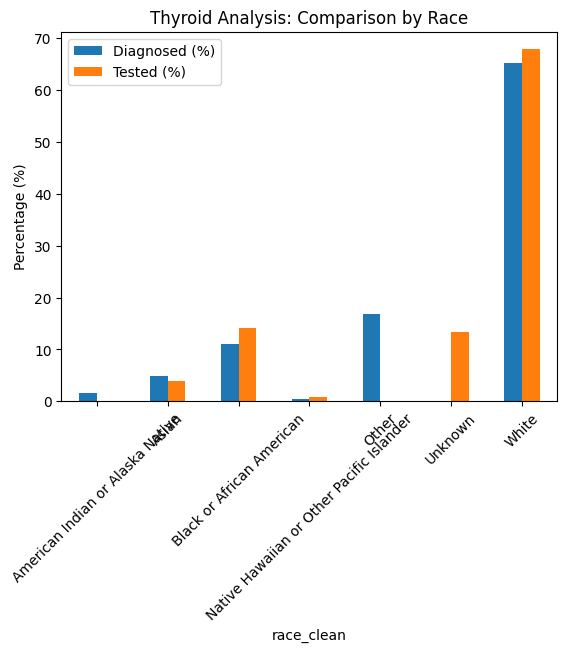

Race Comparison Table:
                                           Diagnosed (%)  Tested (%)
race_clean                                                          
American Indian or Alaska Native                    1.59        0.06
Asian                                               4.86        3.91
Black or African American                          11.07       14.06
Native Hawaiian or Other Pacific Islander           0.42        0.88
Other                                              16.83        0.00
Unknown                                             0.00       13.31
White                                              65.24       67.78


In [7]:
# Calculate percentages for race distribution
diag_race = df_diag_unique['race_clean'].value_counts(normalize=True) * 100
test_race = df_test['race_clean'].value_counts(normalize=True) * 100

# Create comparison table and plot
df_race_comp = pd.DataFrame({'Diagnosed (%)': diag_race, 'Tested (%)': test_race}).fillna(0)
df_race_comp.plot(kind='bar', title='Thyroid Analysis: Comparison by Race')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45) # Rotate names if they are too long
plt.show()

# Display numeric results
print("Race Comparison Table:")
print(df_race_comp.round(2))

Data quality issue: discrepant coding between systems
Other vs Unkown

A critical disparity was found in the American Indian/Alaska Native population, showing a near-absence of diagnostic testing despite recorded diagnoses.

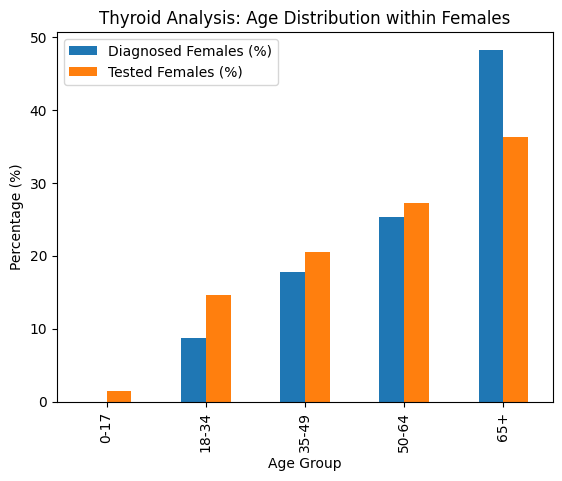

Female Age Group Comparison Table:
           Diagnosed Females (%)  Tested Females (%)
age_group                                           
0-17                        0.00                1.40
18-34                       8.70               14.63
35-49                      17.82               20.46
50-64                      25.23               27.25
65+                        48.23               36.26


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. FILTER DATA FOR FEMALES ONLY ---
# Create female-only cohorts for both diagnosed and tested groups
df_female_diag = df_diag_unique[df_diag_unique['gender_clean'] == 'F']
df_female_test = df_test_unique[df_test_unique['gender_clean'] == 'F']

# --- 2. CALCULATE AGE DISTRIBUTION WITHIN FEMALES ---
# Calculate percentages for age groups within the female cohort
diag_female_age = df_female_diag['age_group'].value_counts(normalize=True).sort_index() * 100
test_female_age = df_female_test['age_group'].value_counts(normalize=True).sort_index() * 100

# --- 3. CREATE COMPARISON TABLE AND PLOT ---
df_female_age_comp = pd.DataFrame({
    'Diagnosed Females (%)': diag_female_age, 
    'Tested Females (%)': test_female_age
}).fillna(0)

df_female_age_comp.plot(kind='bar', title='Thyroid Analysis: Age Distribution within Females')
plt.ylabel('Percentage (%)')
plt.xlabel('Age Group')
plt.show()

# Display numeric results
print("Female Age Group Comparison Table:")
print(df_female_age_comp.round(2))

While the data supports the expected clinical trend of high risk in women aged 35-64, it also reveals a significant 'Screening Gap' in the 65+ population.

Narrative Draft: 
Diagnosed Cohort: 32,231 unique patients with thyroid-related diagnoses.

Tested Cohort: 42,300 unique patients who received TSH, T3, or T4 testing.

2. Key Findings
Gender: High Risk in Females
Finding: Females represent 74% of the diagnosed population, confirming the expected clinical trend.

Gap: Only 65% of the tested population are female. This suggests a screening gap where high-risk females may be under-tested compared to males.

Age: Risk Increases with Age
40s-50s Trend: Patients aged 35–64 show proactive screening. Their testing rates (47.6%) exceed their diagnosis rates (43.0%), aligning with clinical guidelines for this high-risk group.

The 65+ Gap: The 65+ group is the largest diagnosed segment (48.2%), yet they receive only 36.3% of the tests. This indicates a significant under-screening of the elderly population.

Race: Data Quality & Disparities
White Population: Represents the majority (~65%) in both cohorts, with testing rates well-aligned with prevalence.

Critical Disparity: The American Indian/Alaska Native group shows a near-total absence of testing (0.06%) despite having recorded diagnoses (1.59%).

Data Issue: Discrepancies between "Other" and "Unknown" suggest inconsistent coding between clinical and laboratory systems.

3. Conclusion
The data reflects real-world clinical trends, particularly the high prevalence in women and the increased risk with age. However, there is a clear mismatch between risk and resource allocation:

Over-testing in younger and male populations.

Under-testing in high-risk elderly and specific minority groups (AI/AN).